In [1]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt
import pyross
import time 

In [2]:
# Population
N = float(1e4) # full population size
M = 2 # just one age group to begin
Ni = np.array([2e3, 8e3]) # Array of age group sizes

# Contact Matrix
CM = np.zeros((M, M))
def contactMatrix(t):
    CM = np.array([[1, 1], [1, 1]], dtype='float')
    return CM

# Time since infection: cut-off + discretisation
tsi_max = 20 # days
kI = 200
Tf = 200 # days

beta0 = 0.2
gamma0 = 1/7 
beta = np.full((kI), beta0)
tsi = np.linspace(0, tsi_max, kI)
gamma = gamma0/(1-np.exp(-gamma0*(tsi_max-tsi+1)))



# Sort parameters into a dictionary
parameters = {'beta': beta,
              'gI': gamma}
model = pyross.tsi.deterministic.SIR(parameters, M, Ni, kI, tsi_max)

# 4 infectives at t=0
I0 = np.zeros((M*kI))
I0[0] = 1 

# N-4 susceptibles at t=0
S0 = Ni
x0 = np.concatenate([S0, I0])
X = model.simulate(x0, contactMatrix, Tf)

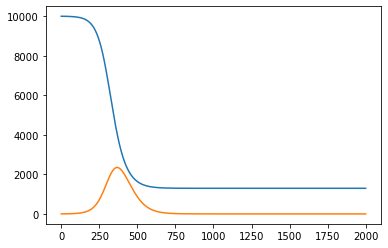

In [3]:
plt.plot(np.sum(X[:, 0:M], axis=-1))
plt.plot(np.sum(X[:, M:], axis=1))
plt.show() 

In [4]:
estimator = pyross.tsi.inference.SIR(parameters, M, Ni, kI, tsi_max)

In [5]:
start_time = time.time() 

N_start = 250
Nf_inference = 50
inter_steps = 5 # internal number of steps between two data points 

x = X[N_start:N_start+Nf_inference:inter_steps]
Tf_inference = (Nf_inference-inter_steps)*estimator.dt 



logp = estimator.obtain_minus_log_p(parameters, x, Tf_inference, contactMatrix, inter_steps=inter_steps, tangent=False)
xm, cov = estimator.obtain_full_mean_cov(x[0], Tf_inference, int(Nf_inference/inter_steps), inter_steps)
end_time = time.time()
print(logp)
print(end_time - start_time)

not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
-2364.4419943851917
2.1555659770965576


In [6]:
print(estimator.J_mat)

[[ -0.06095015   0.          -0.07110558 ...  -0.03555279  -0.07110558
   -0.01777639]
 [  0.          -0.06095015  -0.28442232 ...  -0.14221116  -0.28442232
   -0.07110558]
 [  0.06095015   0.          -9.92889442 ...   0.03555279   0.07110558
    0.01777639]
 ...
 [  0.           0.           0.         ... -10.           0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]
 [  0.           0.           0.         ...   9.0180248    0.
    0.        ]]


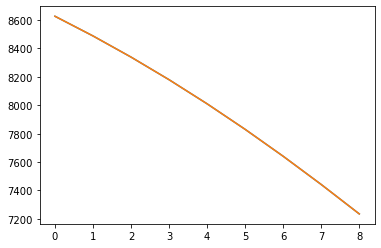

In [7]:
# check that the mean agrees with the det traj 
plt.plot(np.sum(xm[:, :M], axis=1))
plt.plot(np.sum(x[1:, :M], axis=1))
plt.show()

In [ ]:
prior_dict = {
                'beta':{
                    'mean': beta,
                    'infer_scale': True,
                    'scale_factor_std': 1,
                    'scale_factor_bounds': [0.1, 10],
                    'prior_fun': 'truncnorm'
                },
                'gI':{
                    'mean': gamma,
                    'infer_scale': True,
                    'scale_factor_std': 1,
                    'scale_factor_bounds': [0.1, 10],
                    'prior_fun': 'truncnorm'
                }
            }

# very important to set inter_steps=1
result = estimator.infer(x, Tf_inference, prior_dict, contactMatrix=contactMatrix,
              verbose=True, ftol=1e-6, inter_steps=inter_steps,
              global_max_iter=10, local_max_iter=5, global_atol=1.,
              enable_global=True, enable_local=True)

Starting global minimisation...
(8_w,16)-aCMA-ES (mu_w=4.8,w_1=32%) in dimension 2 (seed=4088758213, Wed Oct 14 14:08:53 2020)
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos def
not pos d

In [16]:
print(result['flat_params']) # MAP estimates for scale factors 

[0.99449892 0.88904875]


In [17]:
# check the mean traj of the optimised parameters 
estimator.set_params(result['params_dict'])
xm, cov = estimator.obtain_full_mean_cov(x[0], Tf_inference, x.shape[0], inter_steps)

In [18]:
estimator.obtain_minus_log_p(result['params_dict'], x, Tf_inference, contactMatrix, inter_steps=inter_steps, tangent=False)

992.162576858666

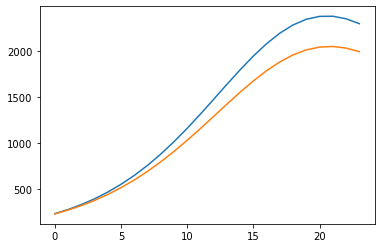

In [19]:
plt.plot(np.sum(xm[:, M:], axis=1))
plt.plot(np.sum(x[1:, M:], axis=1))
plt.show() 

In [14]:
print(np.diag(cov))

[12.75545099 51.02180396 14.23374829 ...  3.45019777  2.78059408
 11.16437084]
